# Sudden Expansion of an Infinite Spherical Well

Consider a particle that is initially confined to an infinite spherical well potential of radius $a$, at an eigenstate $|Nlm\rangle$. Then, the radius of the well suddenly doubles form $a$ to $2a$. The goal is to study what will happen to the particle.
At the instant when the radius of the well doubles, $t = 0$, the wavefunction will momentarily stay the same way it was before, but it will no longer be in an eigenstate of the potential it is in. Thus, its wavefunction won't be stationary, and in order to solve for its future wavefunction, it's initial one must be expanded in the new eigenfunction basis.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sudden_expansion import P_r

##  1. Parameters

First, choose the initial quantum state, the initial wave radius, and the upper bound of the summation used to approximate the expansion. In this example, I'll use the ground state for a particle, and natural units with $\hbar = m = 1$.

In [2]:
N = 1 #The radial quantum number
l = 0 #The angular momentum quantum number
m = 0 #The magnetic quantum number (not to be confused with mass)

a = 1.0 #Initial radius of the well

N_max = 100

hbar = 1.0
mass = 1.0

## 2. Radial Grid

The radial coordinate is sampled from the center of the expanded well to its boundary, $0 \leq r \leq 2a$.

In [3]:
r = np.linspace(0, 2 * a, 1000)

## 3. Radial Probability Density

The radial probability density is:
$$ P(r, t) = r ^ 2 |R(r, t)| ^ 2$$

I first graph this function at $t = 0$, immediately after the radius doubles.

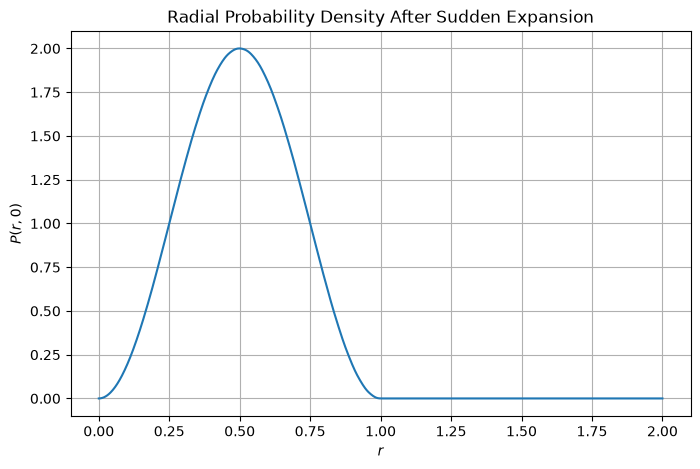

In [4]:
P = P_r(r, 0, N, l, a, N_max)

plt.figure(figsize = (8, 5))
plt.plot(r, P)
plt.xlabel(r"$r$")
plt.ylabel(r"$P(r, 0)$")
plt.title("Radial Probability Density After Sudden Expansion")
plt.grid()
plt.show()

## 4. Time Evolution

I now visualize the radial probability density as an animation after the radius of the well doubles. The resulting animation is also saved as a GIF.

In [5]:
t_max = 10
n_frames = 100

times = np.linspace(0, t_max, n_frames)

In [6]:
# Precomputing the time-independent quantities

from sudden_expansion import alpha_N_prime
from spherical_well import E, R

N_primes = np.arange(1, N_max + 1)

alphas = np.array([alpha_N_prime(N_prime, N, l, a) for N_prime in N_primes])
energies = np.array([E(N_prime, l, 2 * a) for N_prime in N_primes])
wavefunctions = np.array([R(r, N_prime, l, 2 * a) for N_prime in N_primes])

In [7]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

In [8]:
fig, ax = plt.subplots(figsize = (8, 5))

line, = ax.plot(r, P_r(r, 0, N, l, a, N_max))

ax.set_xlim(0, 2 * a)
ax.set_ylim(0, 3)
ax.set_xlabel(r"$r$")
ax.set_ylabel(r"P(r, t)$")
ax.set_title("Radial Probability Density")
ax.grid()

def update(frame):
    t = times[frame]

    phases = np.exp(-1j * energies * t)

    R_t = np.sum(alphas[:, np.newaxis] * wavefunctions * phases[:, np.newaxis], axis = 0)
    P = r ** 2 * np.abs(R_t) ** 2

    line.set_ydata(P)
    ax.set_title(f"Radial Probability Density, t = {t:.2f}")
    return line,

animation = FuncAnimation(fig, update, frames = n_frames, interval = 101, blit = True)

plt.close(fig)

HTML(animation.to_jshtml())

In [9]:
animation.save("expanding_well.gif", writer = "pillow", fps = 10)